In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
from compressibleSPH.systemv3 import sampleInitialWaveState
from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured



Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
from compressibleSPH.config import SimulationConfig
from sod import sodInitialState, buildSod1D
from util import *
from sodUtil import plotSod
from sodSolution import solve


nx = 800
gamma = 5/3
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 4
smoothIC = True
timeLimit = 0.15

L = 2
dim = 1
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

config = SimulationConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.Wendland2,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta4,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = False,
    cflFactor=0.3,
)

In [3]:
compSystem = buildSod1D(
    nx,
    samplingRatio,
    leftState,
    rightState,
    gamma, config,
    smoothIC
)

Left particles: 800, Right particles: 200
Module sphWarpCore.radiusSearch.wp_compactHash a7913c2 load on device 'cuda:0' took 2.44 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid 1ca7812 load on device 'cuda:0' took 3.10 ms  (cached)
Module sphWarpCore.operations.wp_density 896c489 load on device 'cuda:0' took 2.68 ms  (cached)
Module wp_omega bef00cf load on device 'cuda:0' took 2.85 ms  (cached)


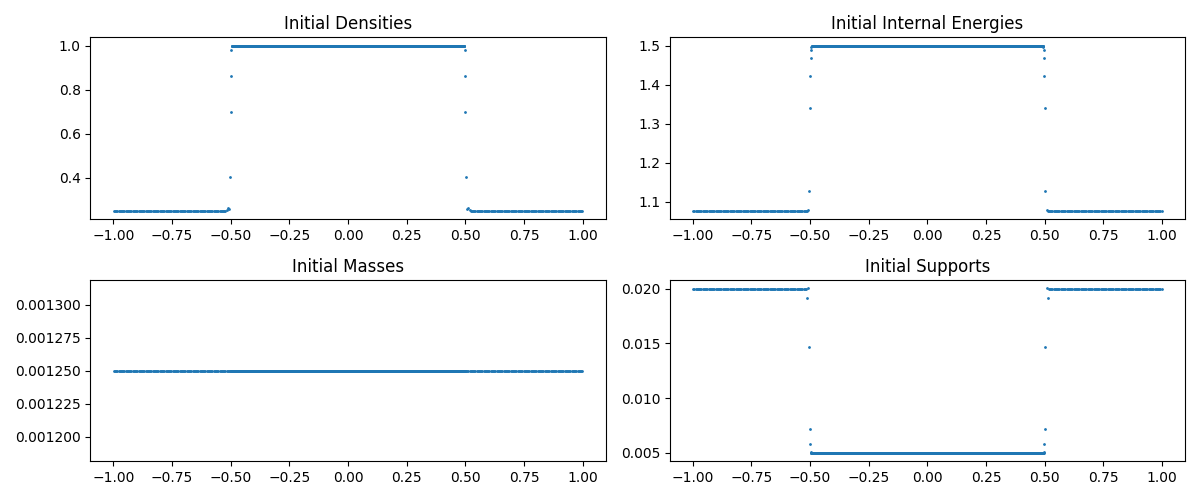

In [4]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], compSystem.state.positions, compSystem.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], compSystem.state.positions, compSystem.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], compSystem.state.positions, compSystem.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], compSystem.state.positions, compSystem.state.supports, title = 'Initial Supports')
fig.tight_layout()

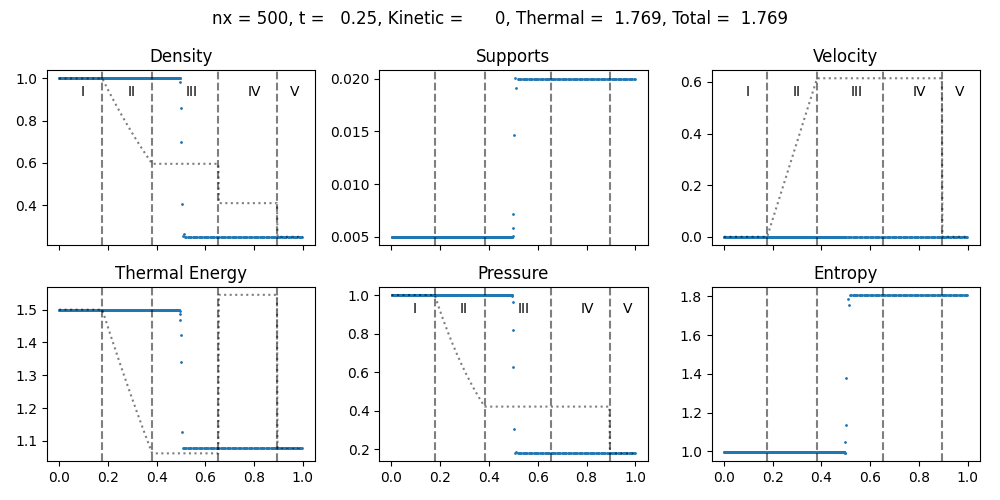

In [5]:
plotSod(compSystem.state, None, None, gamma, leftState, rightState, plotReference = True, plotLabels = True, scatter = True, t_ = 0.25)

In [6]:
from optimalSupport import evaluateOptimalSupport
from eos import idealGasEOS
from wp_omega import computeOmegaWarp
from sphWarpCore import SupportScheme


currentSystem = compSystem.initializeNewState()
currentState = currentSystem.state

rho_optimal, h_optimal, *_ = evaluateOptimalSupport(currentState, config, SupportScheme.Gather)

verletScale = 2 ** (1/config.dim)
verletScale = 1

adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = verletScale, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = currentSystem.adjacency)

numNeighbors = adjacency.numNeighbors

currentState.densities = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = config.supportMode,
    ),
    domain = config.domain,
    adjacency = adjacency,
)

currentState.entropies, _, currentState.pressures, currentState.soundspeeds = idealGasEOS(
    A = None,
    u = currentState.internalEnergies,
    P = None,
    rho = currentState.densities,
    gamma = gamma,
)

omega = computeOmegaWarp(currentState, 
        OperationProperties(
            kernel = config.kernel,
            supportMode = SupportScheme.Gather,
        ),
        domain = config.domain,
        adjacency = adjacency
)
# omega = torch.ones_like(omega)
# currentState.densities = torch.ones_like(currentState.densities)
# currentState.pressures = torch.ones_like(currentState.pressures)
# currentState.masses = torch.ones_like(currentState.masses)

gradHState = GradHState(
    queryOmegas = omega
)

from monaghanScheme import *

dvdt = pressureForce_warp(
    currentState,
    config,
    supportScheme = SupportScheme.KernelMeanSymmetric,
    adjacency = adjacency,
    gradH = gradHState
)

currentState.velocities = torch.sin(currentState.positions[:,0]* np.pi).unsqueeze(-1)

dudt = compute_dudt_warp(
    currentState,
    config,
    supportScheme = SupportScheme.KernelMeanSymmetric,
    adjacency = adjacency,
    gradH = gradHState
)

drhodt = computeMomentumConsistent_warp(
    currentState,
    config,
    supportScheme = SupportScheme.Gather,
    adjacency = adjacency,
    gradH = gradHState
)

# with record_function("[SPH] - 06 - dvdt [pressure]"):
#     dvdt = pressureForce(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, config)

# with record_function("[SPH] - 07 - dvdt [dissipation]"):
#     dvdt_diss = computeViscosity_Monaghan1997(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.Symmetric, config)
#     # dvdt += dvdt_diss
# with record_function("[SPH] - 08 - dudt [velocity]"):
#     dudt = compute_dudt(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.Gather, config)
# with record_function("[SPH] - 09 - dudt [dissipation]"):
#     dudt_diss = computeMonaghan1997Dissipation(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.Symmetric, config)

# with record_function("[CompSPH] - 08 - Compute Density Update"):
#     verbosePrint(verbose, '[CompSPH]\tComputing Density Update')
#     drhodt = computeMomentumConsistent(particles, wrappedKernel, neighbors.get('noghost'), SupportScheme.Gather, config)

# with record_function("[Price07] - 08 - Compute Energy Update"):
#     verbosePrint(verbose, '[Price07]\tComputing Energy Update')
#     dEdt = particles.masses * torch.einsum('ij,ij->i', particles.velocities, (dvdt + dvdt_diss)) + particles.masses * (dudt + dudt_diss)

Module sphWarpCore.operations.wp_gradient f0134b6 load on device 'cuda:0' took 3.62 ms  (cached)
Module sphWarpCore.operations.wp_divergence 5883463 load on device 'cuda:0' took 4.13 ms  (cached)


In [7]:
from wp_diffusion import computeViscosityWarp
from wp_conductivity import computeConductivityWarp
from wp_dissipation import computeThermalDissipationWarp
from sphWarpCore.diffusion.viscosity import DiffusionParameters

diffusionParams = DiffusionParameters()
diffusionParams.c_s = 1
diffusionParams.C_l = 1
diffusionParams.C_q = 2
diffusionParams.Cu_l = 1
diffusionParams.Cu_q = 0
diffusionParams.K = 1.0
diffusionParams.thermalConductivity = 0.5
diffusionParams.viscosityTerm = 7
diffusionParams.thermalConducitiyTerm = 9
diffusionParams.scaleBeta = False
diffusionParams.monaghanSwitch = True
diffusionParams.correctXi = True



dvdt_diss = computeViscosityWarp(
    currentState,
    # queryVelocities=currentState.velocities,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = SupportScheme.KernelMeanSymmetric,
    ),
    domain = config.domain,
    adjacency = adjacency,
    viscosityParams = diffusionParams,
)


dudt_diss = computeConductivityWarp(
    currentState,
    # queryVelocities=currentState.velocities,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = SupportScheme.KernelMeanSymmetric,
    ),
    domain = config.domain,
    adjacency = adjacency,
    conductivityParams = diffusionParams,
)


dudt_thermal = computeThermalDissipationWarp(
    currentState,
    # queryVelocities=currentState.velocities,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = SupportScheme.KernelMeanSymmetric,
    ),
    domain = config.domain,
    adjacency = adjacency,
    conductivityParams = diffusionParams,
)
    #     'C_l': 1,
    #     'C_q': 2,
    #     'Cu_l': 1,
    #     'Cu_q': 2,
    #     'monaghanSwitch': True,
    #     'viscosityTerm': 'Monaghan',
    #     'correctXi': True,
        
    #     'viscosityFormulation': 'Price2012_98',
    #     'thermalConductivityFormulation': 'Price2008',
    #     'signalTerm': 'Price2019',
    #     'K': 1.0,
        
    #     'thermalConductivity' : 0.5,
    # },
    # 'diffusionSwitch':{
    #     'scheme': ViscositySwitch.NoneSwitch,
    #     'limitXi': False,
    # },
    # 'domain': config.domain,
    # 'kernel': KernelType.Wendland2,
    # 'verbose': True,

Module wp_diffusion d16c20f load on device 'cuda:0' took 6.34 ms  (cached)
Module wp_conductivity 8b1ffe7 load on device 'cuda:0' took 7.09 ms  (cached)
Module wp_dissipation bd8b167 load on device 'cuda:0' took 5899.95 ms  (compiled)


In [8]:

# from diffSPH.modules.velocityDiffusion import computeViscosity_Monaghan1997
# from diffSPH.modules.energyDiffusion import computeMonaghan1997Dissipation

In [9]:
from diffSPH.schemes.states.compressiblesph import CompressibleState as CompState
from diffSPH.operations import sph_op, SPHOperation
from diffSPH.schemes.states.wcsph import WeaklyCompressibleState
from diffSPH.schemes.gasDynamics import CompressibleState
from diffSPH.neighborhood import SparseNeighborhood, PrecomputedNeighborhood, SupportScheme, NeighborhoodInformation
from diffSPH.operations import DivergenceMode, GradientMode, Operation, LaplacianMode
from diffSPH.operations import KernelCorrectionScheme, SPHKernel
from typing import Union, Tuple, Dict
from diffSPH.neighborhood import evaluateNeighborhood
from diffSPH.enums import KernelType
from diffSPH.kernels import getSPHKernelv2

from diffSPH.simple import SupportScheme as SupportSchemeDiffSPH, ViscositySwitch
from diffSPH.operations import sph_op
from diffSPH.sphOperations.shared import compute_xij, getTerms
from diffSPH.modules.viscosity import compute_Pi
from diffSPH.modules.adaptiveSmoothingASPH import evaluateOptimalSupportOwen
from diffSPH.schemes.gasDynamics import CompressibleSystem, CompressibleUpdate, CompressibleState
from diffSPH.kernels import evalW, evalGradW, evalDerivativeW
import copy
from diffSPH.modules.velocityDiffusion import computeViscosity_Monaghan1997
from diffSPH.modules.energyDiffusion import computeMonaghan1997Dissipation
from diffSPH.modules.switches.CullenDehnen2010 import computeCullenTerms, computeCullenUpdate
from diffSPH.schemes.gasDynamics import CompressibleSystem, CompressibleUpdate, verbosePrint, checkTensor
from diffSPH.modules.viscositySwitch import computeViscositySwitch, updateViscositySwitch
from diffSPH.neighborhood import SupportScheme, evaluateNeighborhood
from diffSPH.regions import enforceDirichlet, enforceDirichletUpdate, applyForcing
from diffSPH.modules.momentum import computeMomentum, computeMomentumConsistent

def pressureForce(
        particles: Union[CompressibleState, WeaklyCompressibleState],
        kernel: SPHKernel,
        neighborhood: Tuple[SparseNeighborhood, PrecomputedNeighborhood],
        supportScheme: SupportSchemeDiffSPH = SupportSchemeDiffSPH.Gather,
        config: Dict = {}):
    
    rho = particles.densities
    return -SPHOperation(
        particles,
        particles.pressures,
        kernel,
        neighborhood[0],
        neighborhood[1],
        operation = Operation.Gradient,
        supportScheme= supportScheme,
        gradientMode = GradientMode.Symmetric,
        correctionTerms=[KernelCorrectionScheme.gradH]
    ) / rho.view(-1, 1)

def compute_dudt(
        particles: Union[CompressibleState, WeaklyCompressibleState],
        kernel: SPHKernel,
        neighborhood: Tuple[SparseNeighborhood, PrecomputedNeighborhood],
        supportScheme: SupportSchemeDiffSPH = SupportSchemeDiffSPH.Gather,
        config: Dict = {}):
    
    pressure = particles.pressures
    omega = particles.omega if hasattr(particles, 'omega') and particles.omega is not None else torch.ones_like(particles.densities)
    rho = particles.densities

    term = -pressure / (omega * rho)
    return term * SPHOperation(
        particles,
        particles.velocities,
        kernel,
        neighborhood[0],
        neighborhood[1],
        operation = Operation.Divergence,
        supportScheme= supportScheme,
        gradientMode = GradientMode.Difference,
        consistentDivergence=True)


diffSPHState = CompState(
    positions = currentState.positions,
    velocities = currentState.velocities,
    densities = currentState.densities,
    supports = currentState.supports,
    internalEnergies = currentState.internalEnergies,
    totalEnergies = currentState.totalEnergies,
    entropies = currentState.entropies,
    soundspeeds= currentState.soundspeeds,
    masses = currentState.masses,
    kinds = currentState.kinds,
    materials = currentState.materials,
    UIDs = currentState.UIDs,
    pressures = currentState.pressures,
    omega = gradHState.queryOmegas,
)

wrappedKernel = getSPHKernelv2(KernelType.Wendland2)
verletScale = 2 ** (1/config.dim)
verletScale = 1

neighborhood, neighbors = evaluateNeighborhood(diffSPHState, config.domain, KernelType.Wendland2, verletScale = verletScale, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)



dvdt_diffSPH = pressureForce(
    diffSPHState,
    wrappedKernel,
    neighbors.get('noghost'),
    supportScheme = SupportSchemeDiffSPH.Symmetric,
) 

dudt_diffSPH = compute_dudt(
    diffSPHState,
    wrappedKernel,
    neighbors.get('noghost'),
    supportScheme = SupportSchemeDiffSPH.Symmetric,
)

diffSPHDiffusionConfig = {    
    'diffusion':{
        'C_l': 1,
        'C_q': 2,
        'Cu_l': 1,
        'Cu_q': 0,
        'monaghanSwitch': True,
        'viscosityTerm': 'Monaghan',
        'correctXi': True,
        
        'viscosityFormulation': 'Price2012_98',
        'thermalConductivityFormulation': 'Price2008',
        'signalTerm': 'Price2019',
        'K': 1.0,
        
        'thermalConductivity' : 0.5,
    },
    'diffusionSwitch':{
        'scheme': ViscositySwitch.NoneSwitch,
        'limitXi': False,
    },
    'domain': config.domain,
    'kernel': KernelType.Wendland2,
    'verbose': True,
}

# diffSPHState.soundspeeds = torch.ones_like(diffSPHState.soundspeeds)

from diffSPH.modules.energyDiffusion import computeThermalConductivity_Monaghan1997, computeThermalDissipation_Monaghan1997

dvdt_diss_diffSPH = computeViscosity_Monaghan1997(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.Symmetric, diffSPHDiffusionConfig)
# dvdt += dvdt_diss
dudt_diss_diffSPH = computeThermalConductivity_Monaghan1997(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.Symmetric, diffSPHDiffusionConfig)

dudt_thermal_diffSPH = computeThermalDissipation_Monaghan1997(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.Symmetric, diffSPHDiffusionConfig)

drhodt_diffSPH = computeMomentumConsistent(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.Gather, config)

# dEdt_diffSPH = diffSPHState.masses * torch.einsum('ij,ij->i', diffSPHState.velocities, (dvdt_diffSPH + dvdt_diss_diffSPH)) + diffSPHState.masses * (dudt_diffSPH + dudt_diss_diffSPH)

tensor(0.1143, device='cuda:0') tensor(0.1055, device='cuda:0')
 ratio:  tensor(0.9226, device='cuda:0')


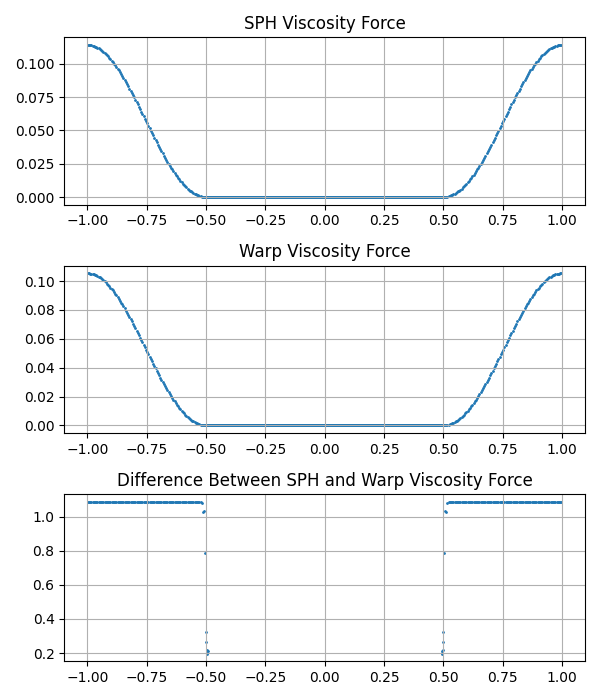

In [ ]:
fig, axis = plt.subplots(3,1, figsize = (6, 7), squeeze = False)

axis[0,0].scatter(diffSPHState.positions[:,0].cpu(), dudt_thermal_diffSPH.cpu(), label = 'SPH Viscosity Force', s = 1)
axis[1,0].scatter(currentState.positions[:,0].cpu(), dudt_thermal.cpu(), label = 'Warp Viscosity Force', s = 1)

diff = dudt_thermal_diffSPH.cpu() - dudt_thermal.cpu()
axis[2,0].scatter(currentState.positions[:,0].cpu(), diff, label = 'Difference', s = 1)
# axis[2,0].legend()

print(dudt_thermal_diffSPH.abs().max(), dudt_thermal.abs().max())
print(' ratio: ', dudt_thermal.abs().max() / dudt_thermal_diffSPH.abs().max())

axis[0,0].set_title('SPH Viscosity Force')
axis[1,0].set_title('Warp Viscosity Force')
axis[2,0].set_title('Difference Between SPH and Warp Viscosity Force')
for ax in axis.flatten():
    ax.grid()

fig.tight_layout()

tensor(12.2701, device='cuda:0') tensor(12.2701, device='cuda:0')
 ratio:  tensor(1.0000, device='cuda:0')


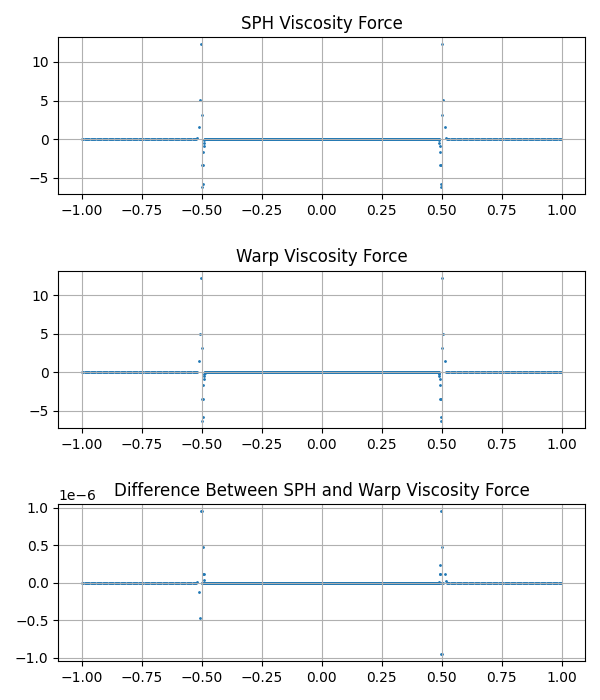

In [11]:
fig, axis = plt.subplots(3,1, figsize = (6, 7), squeeze = False)

axis[0,0].scatter(diffSPHState.positions[:,0].cpu(), dudt_diss_diffSPH.cpu(), label = 'SPH Viscosity Force', s = 1)
axis[1,0].scatter(currentState.positions[:,0].cpu(), dudt_diss.cpu(), label = 'Warp Viscosity Force', s = 1)

diff = dudt_diss_diffSPH.cpu() - dudt_diss.cpu()
axis[2,0].scatter(currentState.positions[:,0].cpu(), diff, label = 'Difference', s = 1)
# axis[2,0].legend()

print(dudt_diss.abs().max(), dudt_diss_diffSPH.abs().max())
print(' ratio: ', dudt_diss.abs().max() / dudt_diss_diffSPH.abs().max())

axis[0,0].set_title('SPH Viscosity Force')
axis[1,0].set_title('Warp Viscosity Force')
axis[2,0].set_title('Difference Between SPH and Warp Viscosity Force')
for ax in axis.flatten():
    ax.grid()

fig.tight_layout()

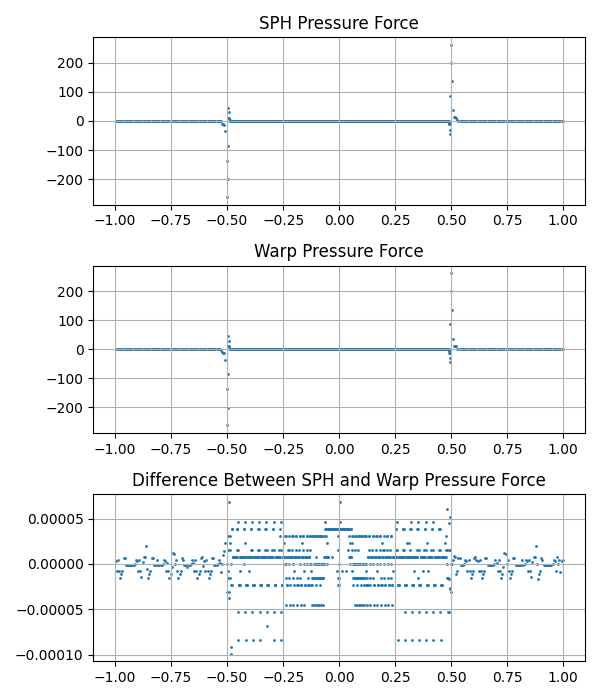

In [12]:
fig, axis = plt.subplots(3,1, figsize = (6, 7), squeeze = False)

axis[0,0].scatter(diffSPHState.positions[:,0].cpu(), dvdt_diffSPH[:,0].cpu(), label = 'SPH Pressure Force', s = 1)
axis[1,0].scatter(currentState.positions[:,0].cpu(), dvdt[:,0].cpu(), label = 'Warp Pressure Force', s = 1)

diff = dvdt_diffSPH[:,0].cpu() - dvdt[:,0].cpu()
axis[2,0].scatter(currentState.positions[:,0].cpu(), diff, label = 'Difference', s = 1)
# axis[2,0].legend()

axis[0,0].set_title('SPH Pressure Force')
axis[1,0].set_title('Warp Pressure Force')
axis[2,0].set_title('Difference Between SPH and Warp Pressure Force')
for ax in axis.flatten():
    ax.grid()

fig.tight_layout()

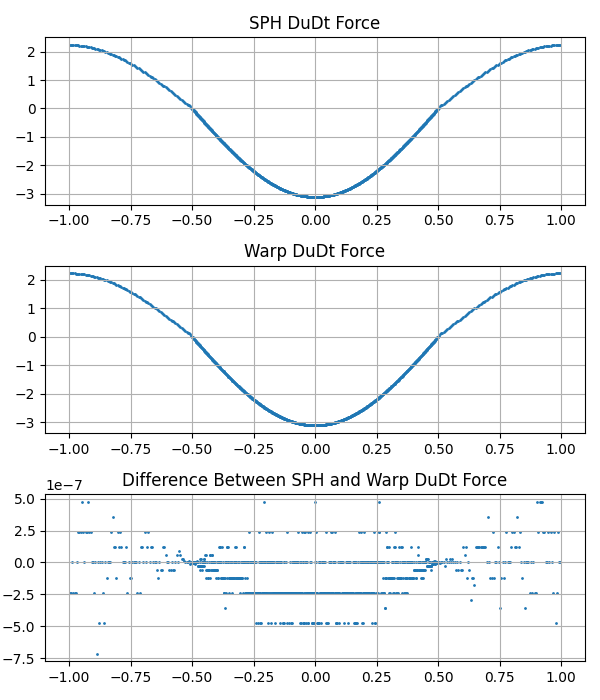

In [13]:
fig, axis = plt.subplots(3,1, figsize = (6, 7), squeeze = False)

axis[0,0].scatter(diffSPHState.positions[:,0].cpu(), dudt_diffSPH.cpu(), label = 'SPH DuDt Force', s = 1)
axis[1,0].scatter(currentState.positions[:,0].cpu(), dudt.cpu(), label = 'Warp DuDt Force', s = 1)

diff = dudt_diffSPH.cpu() - dudt.cpu()
axis[2,0].scatter(currentState.positions[:,0].cpu(), diff, label = 'Difference', s = 1)
# axis[2,0].legend()

axis[0,0].set_title('SPH DuDt Force')
axis[1,0].set_title('Warp DuDt Force')
axis[2,0].set_title('Difference Between SPH and Warp DuDt Force')
for ax in axis.flatten():
    ax.grid()

fig.tight_layout()

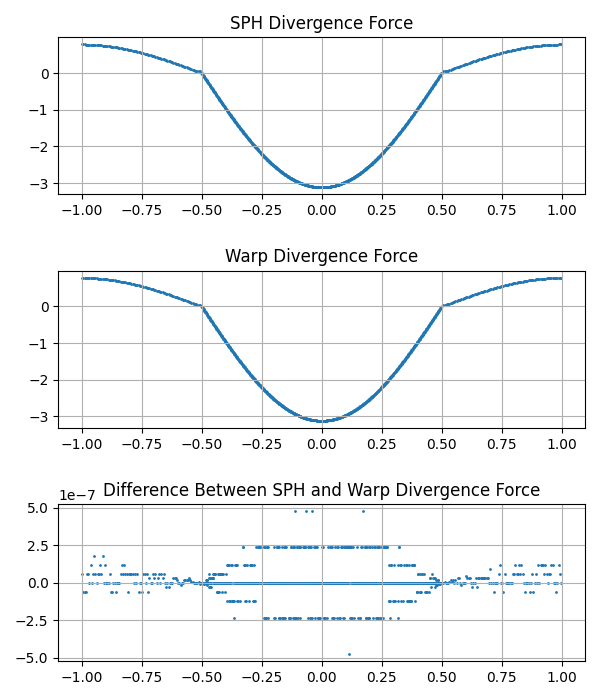

In [14]:
fig, axis = plt.subplots(3,1, figsize = (6, 7), squeeze = False)

axis[0,0].scatter(diffSPHState.positions[:,0].cpu(), drhodt_diffSPH.cpu(), label = 'SPH Divergence Force', s = 1)
axis[1,0].scatter(currentState.positions[:,0].cpu(), drhodt.cpu(), label = 'Warp Divergence Force', s = 1)

diff = drhodt_diffSPH.cpu() - drhodt.cpu()
axis[2,0].scatter(currentState.positions[:,0].cpu(), diff, label = 'Difference', s = 1)
# axis[2,0].legend()

axis[0,0].set_title('SPH Divergence Force')
axis[1,0].set_title('Warp Divergence Force')
axis[2,0].set_title('Difference Between SPH and Warp Divergence Force')
for ax in axis.flatten():
    ax.grid()

fig.tight_layout()

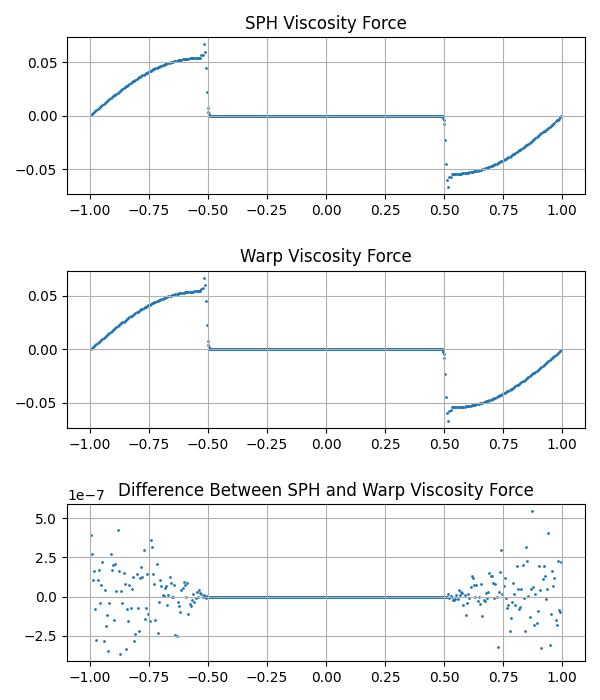

In [15]:
fig, axis = plt.subplots(3,1, figsize = (6, 7), squeeze = False)

axis[0,0].scatter(diffSPHState.positions[:,0].cpu(), dvdt_diss_diffSPH.cpu(), label = 'SPH Viscosity Force', s = 1)
axis[1,0].scatter(currentState.positions[:,0].cpu(), dvdt_diss.cpu(), label = 'Warp Viscosity Force', s = 1)

diff = dvdt_diss_diffSPH.cpu() - dvdt_diss.cpu()
axis[2,0].scatter(currentState.positions[:,0].cpu(), diff, label = 'Difference', s = 1)
# axis[2,0].legend()

axis[0,0].set_title('SPH Viscosity Force')
axis[1,0].set_title('Warp Viscosity Force')
axis[2,0].set_title('Difference Between SPH and Warp Viscosity Force')
for ax in axis.flatten():
    ax.grid()

fig.tight_layout()